In [1]:
import argparse
import re
from pathlib import Path
from typing import Any, Iterable, List, Tuple

import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
import pandas as pd
import seaborn as sns

import utils as project_utils
from utils import safe_name

PROJECT_ROOT = Path(project_utils.__file__).resolve().parent
DEFAULT_RUN_DIR = PROJECT_ROOT / "outputs"



PLOT_METRICS = {
    "type_ii": {
        "column": "Cum. Type-II",
        "filename": "type_ii",
        "title": "Type-II error",
    },
    "type_i": {
        "column": "Cum. Type-I",
        "filename": "type_i",
        "title": "Type-I error",
    },
    "budget": {
        "column": "Cum. Budget",
        "filename": "budget",
        "title": "Budget",
    },
}


# METHOD_ORDER = ["Ours", "Ours-LLM", "Ours-Random", "LLM-Select", "Random"]
METHOD_ORDER = ["Ours", "Ours-LLM", "Ours-Random", "LLM-Select"]
# Edit this list to control which methods are drawn in the final plots.
# It initially includes every implemented method.
METHODS_TO_PLOT = METHOD_ORDER.copy()
METHOD_PALETTE = {
    "Ours": "#F2B701",          # yellow
    "Ours-LLM": "#1f77b4",      # blue
    "Ours-Random": "#9467bd",   # purple
    "LLM-Select": "#d62728",    # red
    "Random": "#2ca02c",        # green
}

# Axis-limit controls. The first few online rounds often contain unstable
# transients that are not representative of the curve and can make paper
# figures visually unreadable. These rounds are still plotted, but are ignored
# only when choosing y-axis limits. Set this to 0 if you want literal min/max.
Y_LIMIT_IGNORE_FIRST_N_ROUNDS = 5
Y_LIMIT_MARGIN_FRAC = 0.08
Y_LIMIT_MIN_POINTS_AFTER_WARMUP = 8


KNOWN_METHOD_PREFIXES = ("llm_select", "ours_llm", "ours_random", "random", "ours")
KNOWN_DATASET_PATTERNS = (
    # These patterns intentionally match dataset ids inside either output-folder
    # names or run-file stems. They stop before the budget/method-parameter suffix.
    r"(gpqa-[^_/]+_[^_/]+_n[^_/]+)(?=_budget|[/\\]|$)",
    r"(mmlupro-[^_/]+_n[^_/]+_seed[^_/]+(?:_(?!budget)[^_/]+)*)(?=_budget|[/\\]|$)",
    r"(popqa-[^_/]+_n[^_/]+_seed[^_/]+(?:_(?!budget)[^_/]+)*)(?=_budget|[/\\]|$)",
    r"(popqa500-[^_/]+_n[^_/]+_seed[^_/]+(?:_(?!budget)[^_/]+)*)(?=_budget|[/\\]|$)",
    r"(math500-[^_/]+)(?=_budget|[/\\]|$)",
)
SHORT_DATASET_ALIASES = {
    "mmlu_pro": "mmlupro",
    "mmlu-pro": "mmlupro",
    "mmlupro500": "mmlupro",
    "popqa500": "popqa",
    "gpqa_diamond": "gpqa",
    "gpqa_main": "gpqa",
    "gpqa_extended": "gpqa",
}


def _first_nonempty(series: pd.Series) -> str | None:
    for value in series.dropna().tolist():
        text = str(value).strip()
        if text:
            return text
    return None


def _normalize_dataset_text(text: Any) -> str:
    """Normalize known dataset aliases without changing method/model names."""
    text = str(text)
    text = text.replace("popqa500-", "popqa-")
    text = text.replace("mmlu_pro", "mmlupro")
    text = text.replace("mmlu-pro", "mmlupro")
    text = text.replace("MMLU-Pro", "mmlupro")
    return text


def _normalize_dataset_id(text: Any) -> str:
    text = safe_name(_normalize_dataset_text(text)).replace("popqa500-", "popqa-")
    return SHORT_DATASET_ALIASES.get(text, text)


def _is_detailed_dataset_id(text: Any) -> bool:
    text = _normalize_dataset_id(text)
    return bool(
        text.startswith("math500-")
        or text.startswith("gpqa-")
        or re.match(r"^(mmlupro|popqa)-[^_]+_n[^_]+_seed[^_]+(?:_(?!budget)[^_]+)*$", text)
    )


def _known_dataset_from_text(text: str) -> str | None:
    """Extract this project's detailed dataset id from a path, run stem, or config name."""
    text = _normalize_dataset_text(text).replace("\\", "/")
    for pattern in KNOWN_DATASET_PATTERNS:
        m = re.search(pattern, text)
        if m:
            return _normalize_dataset_id(m.group(1))
    return None


def infer_dataset_name(csv_path: Path, df: pd.DataFrame) -> str:
    """Infer the detailed dataset identifier for a run CSV.

    Important: some older CSVs contain a short ``dataset`` column such as
    ``mmlupro`` or ``popqa``. That value is not specific enough for plotting, so
    the notebook now prefers the run filename, the ``config`` column, and the
    output folder name. The short CSV column is used only as a fallback.
    """
    candidates: list[str] = []

    if "config" in df.columns:
        config_name = _first_nonempty(df["config"])
        if config_name:
            candidates.append(config_name)

    candidates.extend(
        [
            csv_path.stem,
            csv_path.parent.name,
            str(csv_path),
        ]
    )

    # Prefer detailed ids visible in the run filename or output path.
    for text in candidates:
        known = _known_dataset_from_text(text)
        if known:
            return known

    # Use an explicit dataset column only when it is already detailed. This
    # avoids collapsing all MMLU-Pro/PopQA variants to just "mmlupro"/"popqa".
    if "dataset" in df.columns:
        explicit = _first_nonempty(df["dataset"])
        if explicit:
            explicit = _normalize_dataset_id(explicit)
            if _is_detailed_dataset_id(explicit):
                return explicit
            return explicit

    return safe_name("unknown_dataset")


def infer_model_data_name(csv_path: Path, df: pd.DataFrame) -> str:
    """Infer the figure/output group: {main_llm}_{dataset}."""
    dataset = infer_dataset_name(csv_path, df)
    parent = safe_name(_normalize_dataset_text(csv_path.parent.name)).replace("popqa500-", "popqa-")

    # Preferred path: outputs/{main_llm}_{dataset}/run.csv
    if dataset != "unknown_dataset" and (parent == dataset or parent.endswith("_" + dataset)):
        return parent

    parent_known = _known_dataset_from_text(parent)
    if parent_known and parent_known != "unknown_dataset":
        return parent

    main_llm = _first_nonempty(df["main_llm"]) if "main_llm" in df.columns else None
    if main_llm and dataset != "unknown_dataset":
        return f"{safe_name(main_llm)}_{dataset}"

    # Last fallback: parse the run filename/config column and remove the method prefix.
    text_candidates = [csv_path.stem]
    if "config" in df.columns:
        config_name = _first_nonempty(df["config"])
        if config_name:
            text_candidates.insert(0, config_name)

    for text in text_candidates:
        text = _normalize_dataset_text(text)
        known = _known_dataset_from_text(text)
        if known and known in text:
            prefix = text.split(known, 1)[0].rstrip("_")
            for method in KNOWN_METHOD_PREFIXES:
                method_prefix = method + "_"
                if prefix.startswith(method_prefix):
                    prefix = prefix[len(method_prefix) :]
                    break
            if prefix:
                return safe_name(f"{prefix}_{known}")

    return safe_name(dataset)


def _resolve_run_path(path_like: str | Path) -> Path | None:
    """Resolve a run path robustly from notebooks launched outside the project root."""
    path = Path(path_like).expanduser()
    candidates = [path]
    if not path.is_absolute():
        candidates.extend([PROJECT_ROOT / path, Path.cwd() / path])

    for candidate in candidates:
        if candidate.exists():
            return candidate

    # Common Jupyter case: cwd is the parent of the project folder, while the
    # notebook and outputs live inside that project folder.
    if str(path_like) == "outputs":
        for root in [PROJECT_ROOT, Path.cwd(), *Path.cwd().parents]:
            candidate = root / "outputs"
            if candidate.exists():
                return candidate
            for nested in sorted(root.glob("*/outputs")):
                if nested.exists():
                    return nested

    return None


def collect_run_csvs(paths: List[str]) -> pd.DataFrame:
    frames = []
    scanned_csvs = 0
    loaded_csvs = 0
    missing_paths = []

    for p in paths:
        resolved = _resolve_run_path(p)
        if resolved is None:
            missing_paths.append(str(p))
            continue

        csvs = sorted(resolved.rglob("*.csv")) if resolved.is_dir() else [resolved]
        scanned_csvs += len(csvs)

        for csv in csvs:
            # Skip generation caches and notebook-produced summaries. Keep all
            # method-run CSVs even if they have extra legacy columns.
            if csv.name.startswith("gen_") or csv.name in {"summary_metrics.csv", "per_round_metrics.csv"}:
                continue
            if csv.name.endswith("_metrics.csv"):
                continue

            try:
                df = pd.read_csv(csv)
            except Exception as exc:
                print(f"[plot][skip] could not read {csv}: {exc}")
                continue

            required = {"method", "t", "selected", "A", "cost", "budget"}
            missing_required = required.difference(df.columns)
            if missing_required:
                print(f"[plot][skip] {csv} is not a method-run CSV; missing {sorted(missing_required)}")
                continue

            df["run_file"] = csv.stem.replace("popqa500-", "popqa-")
            df["run_path"] = str(csv)
            df["dataset"] = infer_dataset_name(csv, df)
            df["model_data"] = infer_model_data_name(csv, df)
            frames.append(df)
            loaded_csvs += 1

    if missing_paths:
        print(f"[plot][warn] these run paths were not found: {missing_paths}")
    print(f"[plot] scanned {scanned_csvs} CSV files; loaded {loaded_csvs} method-run CSV files.")

    if not frames:
        raise RuntimeError(
            "No method run CSV files found. Check that the notebook is using the right outputs directory. "
            f"PROJECT_ROOT={PROJECT_ROOT} cwd={Path.cwd()}"
        )

    out = pd.concat(frames, ignore_index=True)
    discovered = sorted(out[["model_data", "dataset"]].drop_duplicates().itertuples(index=False, name=None))
    print("[plot] discovered run groups:")
    for model_data, dataset in discovered:
        print(f"  - {model_data}  |  {dataset}")
    return out


def pretty_method(name: str) -> str:
    key = str(name).strip().lower().replace("-", "_").replace(" ", "_")
    mapping = {
        "ours": "Ours",
        "ours_llm": "Ours-LLM",
        "ours_random": "Ours-Random",
        "random": "Random",
        "llm_select": "LLM-Select",
        "llm_selects": "LLM-Select",
    }
    return mapping.get(key, str(name))


def safe_div(num: float, den: float) -> float:
    return 0.0 if den <= 0 else float(num / den)


def summarize_per_round(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["model_data", "dataset", "config", "method", "run_file", "t"]

    for (model_data, dataset, config, method, run_file, t), g in df.groupby(group_cols, sort=True):
        selected = g["selected"].astype(int)
        A = g["A"].astype(int)
        cost = g["cost"].astype(float)

        n_sel = int(selected.sum())
        n_unsel = int((1 - selected).sum())

        selected_correct = float((selected * (1 - A)).sum())
        unselected_wrong = float(((1 - selected) * A).sum())
        used_budget = float((selected * cost).sum())

        rows.append(
            {
                "model_data": model_data,
                "dataset": dataset,
                "config": config,
                "method": method,
                "run_file": run_file,
                "Method": pretty_method(method),
                "Round": int(t),
                "Type-I": safe_div(selected_correct, n_sel),
                "Type-II": safe_div(unselected_wrong, n_unsel),
                "Budget": used_budget,
                "Limit": float(g["budget"].iloc[0]),
                "Selected": n_sel,
                "Unselected": n_unsel,
                "Selected correct": selected_correct,
                "Unselected wrong": unselected_wrong,
            }
        )

    return pd.DataFrame(rows)


def add_cumulative_metrics(round_df: pd.DataFrame) -> pd.DataFrame:
    round_df = round_df.sort_values(
        ["model_data", "dataset", "config", "method", "run_file", "Round"]
    ).reset_index(drop=True)

    group_cols = ["model_data", "dataset", "config", "method", "run_file"]
    round_index = round_df.groupby(group_cols).cumcount() + 1

    round_df["Cum. Type-I"] = round_df.groupby(group_cols)["Type-I"].cumsum() / round_index
    round_df["Cum. Type-II"] = round_df.groupby(group_cols)["Type-II"].cumsum() / round_index
    round_df["Cum. Budget"] = round_df.groupby(group_cols)["Budget"].cumsum() / round_index
    round_df["Avg. Budget"] = round_df["Cum. Budget"]

    round_df["Cum. Selected"] = round_df.groupby(group_cols)["Selected"].cumsum()
    round_df["Cum. Unselected"] = round_df.groupby(group_cols)["Unselected"].cumsum()
    round_df["Cum. Selected correct"] = round_df.groupby(group_cols)["Selected correct"].cumsum()
    round_df["Cum. Unselected wrong"] = round_df.groupby(group_cols)["Unselected wrong"].cumsum()

    round_df["Pooled Type-I"] = round_df.apply(
        lambda r: safe_div(r["Cum. Selected correct"], r["Cum. Selected"]),
        axis=1,
    )
    round_df["Pooled Type-II"] = round_df.apply(
        lambda r: safe_div(r["Cum. Unselected wrong"], r["Cum. Unselected"]),
        axis=1,
    )

    return round_df


def maybe_add_epsilon(metrics: pd.DataFrame, raw_df: pd.DataFrame) -> pd.DataFrame:
    if "epsilon" not in raw_df.columns:
        metrics["epsilon"] = pd.NA
        return metrics

    eps = raw_df[["model_data", "dataset", "config", "method", "run_file", "epsilon"]].drop_duplicates()
    eps = eps.dropna(subset=["epsilon"])
    if eps.empty:
        metrics["epsilon"] = pd.NA
        return metrics

    return metrics.merge(eps, on=["model_data", "dataset", "config", "method", "run_file"], how="left")


def filter_methods_for_plot(
    metrics: pd.DataFrame,
    methods_to_plot: List[str] = METHODS_TO_PLOT,
) -> pd.DataFrame:
    """Keep only the methods listed in METHODS_TO_PLOT before plotting."""
    if metrics.empty or "Method" not in metrics.columns:
        return metrics
    return metrics[metrics["Method"].isin(methods_to_plot)].copy()



def _with_plot_round(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with a one-based x-axis column for plotting.

    Existing CSVs are not modified. If a run already starts at round 1, the
    values are left unchanged; if it starts at 0, plotted rounds become 1..T.
    """
    out = df.copy()
    if "Round" not in out.columns:
        return out

    rounds = pd.to_numeric(out["Round"], errors="coerce")
    min_round = rounds.dropna().min() if rounds.notna().any() else 1
    offset = 1 - float(min_round) if pd.notna(min_round) and float(min_round) < 1 else 0.0
    out["Plot Round"] = rounds + offset
    return out


def _set_plot_limits(
    ax: plt.Axes,
    df: pd.DataFrame,
    y_col: str,
    reference_values: Iterable[float] | None = None,
    y_margin_frac: float = Y_LIMIT_MARGIN_FRAC,
    x_col: str = "Plot Round",
    ignore_first_n_rounds: int = Y_LIMIT_IGNORE_FIRST_N_ROUNDS,
) -> None:
    """Set independent x/y limits for one subplot with robust warm-up handling.

    The limit calculation is intentionally local to the given ``ax`` and
    ``df``. Each subplot therefore gets its own scale. To avoid one or two
    unstable initial points making the entire panel unreadable, the first
    ``ignore_first_n_rounds`` plotted rounds are ignored for y-limit selection
    only; the points are still drawn on the plot and may be clipped if they lie
    outside the chosen paper-facing range.
    """
    if df.empty or y_col not in df.columns:
        return

    plot_df = df.copy()
    y_series = pd.to_numeric(plot_df[y_col], errors="coerce")

    # Choose x limits from all visible data and force one-based display.
    if x_col in plot_df.columns:
        x_values = pd.to_numeric(plot_df[x_col], errors="coerce").dropna()
        if not x_values.empty:
            ax.set_xlim(max(1.0, float(x_values.min())), float(x_values.max()))

    # Use post-warm-up values for y limits when enough values remain.
    limit_mask = y_series.notna()
    if x_col in plot_df.columns and ignore_first_n_rounds > 0:
        x_series = pd.to_numeric(plot_df[x_col], errors="coerce")
        warmup_mask = x_series > (1 + ignore_first_n_rounds)
        if int((limit_mask & warmup_mask).sum()) >= Y_LIMIT_MIN_POINTS_AFTER_WARMUP:
            limit_mask = limit_mask & warmup_mask

    y_values = y_series[limit_mask].dropna().astype(float).tolist()

    # Reference lines are included in the limit only when they are close enough
    # to the visible post-warm-up data. This keeps an extreme reference from
    # destroying the scale while still showing ordinary epsilon/budget guides.
    if reference_values is not None and y_values:
        base_min = min(y_values)
        base_max = max(y_values)
        base_span = max(base_max - base_min, abs(base_min), abs(base_max), 1e-12)
        ref_pad = 0.35 * base_span
        for value in reference_values:
            try:
                if pd.notna(value):
                    value = float(value)
                    if (base_min - ref_pad) <= value <= (base_max + ref_pad):
                        y_values.append(value)
            except Exception:
                pass

    if not y_values:
        y_values = y_series.dropna().astype(float).tolist()
    if not y_values:
        return

    y_min = min(y_values)
    y_max = max(y_values)
    span = y_max - y_min
    if span <= 0:
        span = max(abs(y_min), abs(y_max), 1.0)
    margin = y_margin_frac * span
    ax.set_ylim(y_min - margin, y_max + margin)

def set_paper_style() -> None:
    sns.set_theme(context="paper", style="darkgrid", font_scale=1.2)
    plt.rcParams.update(
        {
            "figure.dpi": 150,
            "savefig.dpi": 300,
            "axes.linewidth": 0.9,
            "legend.frameon": False,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )


def _pad_ylim_for_reference_line(ax: plt.Axes, y_value: float) -> None:
    """Ensure an annotated horizontal reference line is not clipped."""
    ymin, ymax = ax.get_ylim()
    if ymin <= y_value <= ymax:
        return

    span = ymax - ymin
    if span <= 0:
        span = max(abs(y_value), 1.0)

    pad = 0.06 * span
    ymin = min(ymin, y_value - pad)
    ymax = max(ymax, y_value + pad)
    ax.set_ylim(ymin, ymax)


def _annotate_reference_line(ax: plt.Axes, y_value: float, text: str) -> None:
    """Place a reference-line label just inside the plotting area, near the y-axis."""
    _pad_ylim_for_reference_line(ax, y_value)
    transform = blended_transform_factory(ax.transAxes, ax.transData)
    ax.text(
        0.015,
        y_value,
        text,
        transform=transform,
        ha="left",
        va="bottom",
        fontsize=9.5,
        color="black",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.0},
        clip_on=False,
    )


def _draw_metric_axis(metrics: pd.DataFrame, metric_key: str, ax: plt.Axes, legend: bool) -> None:
    meta = PLOT_METRICS[metric_key]
    y = meta["column"]
    plot_df = _with_plot_round(metrics)
    reference_values: list[float] = []

    sns.lineplot(
        data=plot_df,
        x="Plot Round",
        y=y,
        hue="Method",
        hue_order=[m for m in METHOD_ORDER if m in set(metrics["Method"])],
        palette=METHOD_PALETTE,
        linewidth=2.0,
        errorbar=None,
        legend=legend,
        ax=ax,
    )

    if metric_key == "type_i" and "epsilon" in plot_df.columns and plot_df["epsilon"].notna().any():
        epsilon = float(plot_df["epsilon"].dropna().iloc[0])
        reference_values.append(epsilon)
        ax.axhline(
            epsilon,
            linestyle="--",
            linewidth=1.3,
            color="black",
            label="_nolegend_",
        )
        _annotate_reference_line(ax, epsilon, r"$\epsilon$")

    if metric_key == "budget":
        limit = float(plot_df["Limit"].dropna().iloc[0])
        reference_values.append(limit)
        ax.axhline(
            limit,
            linestyle="--",
            linewidth=1.3,
            color="black",
            label="_nolegend_",
        )
        _annotate_reference_line(ax, limit, "Limit")

    _set_plot_limits(ax, plot_df, y, reference_values=reference_values)

    ax.set_xlabel("Round")
    ax.set_ylabel("")
    ax.set_title(meta["title"])
    ax.grid(axis="y", alpha=0.22, linewidth=0.7)
    sns.despine(ax=ax)


def _dedupe_legend(handles: Iterable[Any], labels: Iterable[str]) -> Tuple[List[Any], List[str]]:
    seen = set()
    out_handles = []
    out_labels = []
    for handle, label in zip(handles, labels):
        if not label or label.startswith("_") or label in seen:
            continue
        seen.add(label)
        out_handles.append(handle)
        out_labels.append(label)
    return out_handles, out_labels


def save_metric_plot(metrics: pd.DataFrame, metric_key: str, out_dir: Path) -> None:
    meta = PLOT_METRICS[metric_key]

    fig, ax = plt.subplots(figsize=(4.35, 2.85))
    _draw_metric_axis(metrics, metric_key, ax=ax, legend=True)

    handles, labels = _dedupe_legend(*ax.get_legend_handles_labels())
    if handles:
        ax.legend(handles, labels, title=None, loc="best")

    fig.tight_layout(pad=0.35)
    for ext in ["pdf", "png"]:
        fig.savefig(out_dir / f"{meta['filename']}.{ext}", bbox_inches="tight")
    plt.close(fig)


def save_combined_metric_plot(metrics: pd.DataFrame, out_dir: Path) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.25))

    all_handles: List[Any] = []
    all_labels: List[str] = []
    for ax, key in zip(axes, ["type_ii", "type_i", "budget"]):
        _draw_metric_axis(metrics, key, ax=ax, legend=True)
        handles, labels = ax.get_legend_handles_labels()
        all_handles.extend(handles)
        all_labels.extend(labels)
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    handles, labels = _dedupe_legend(all_handles, all_labels)
    if handles:
        ncol = min(max(len(labels), 1), 6)
        fig.legend(
            handles,
            labels,
            title=None,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=ncol,
            frameon=False,
        )

    fig.tight_layout(rect=(0.0, 0.13, 1.0, 1.0), pad=0.45, w_pad=1.8)
    for ext in ["pdf", "png"]:
        fig.savefig(out_dir / f"combined_metrics.{ext}", bbox_inches="tight")
    plt.close(fig)


def print_final_summary(metrics: pd.DataFrame, model_data: str) -> None:
    final_rows = (
        metrics.sort_values(["model_data", "dataset", "config", "method", "run_file", "Round"])
        .groupby(["model_data", "dataset", "config", "method", "run_file"], as_index=False)
        .tail(1)
    )

    cols = [
        "Method",
        "Round",
        "Cum. Type-I",
        "Cum. Type-II",
        "Pooled Type-I",
        "Pooled Type-II",
        "Cum. Budget",
        "Limit",
    ]

    print()
    print(f"[plot] final cumulative summary for {model_data}")
    print(final_rows[cols].to_string(index=False))


def write_group_plots(raw_df: pd.DataFrame, root_out_dir: Path, model_data: str) -> None:
    out_dir = root_out_dir / safe_name(model_data)
    out_dir.mkdir(parents=True, exist_ok=True)

    per_round = summarize_per_round(raw_df)
    metrics = add_cumulative_metrics(per_round)
    metrics = maybe_add_epsilon(metrics, raw_df)
    metrics = filter_methods_for_plot(metrics)

    per_round_path = out_dir / "per_round_metrics.csv"
    metrics_path = out_dir / "summary_metrics.csv"
    per_round.to_csv(per_round_path, index=False)
    metrics.to_csv(metrics_path, index=False)
    print(f"[plot] wrote {per_round_path}")
    print(f"[plot] wrote {metrics_path}")

    for key in ["type_ii", "type_i", "budget"]:
        save_metric_plot(metrics, key, out_dir)
    save_combined_metric_plot(metrics, out_dir)

    print_final_summary(metrics, model_data)
    print(f"[plot] wrote figures to {out_dir}")


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--runs",
        nargs="+",
        default=["outputs"],
        help="Run CSVs or output directories. Directories are scanned recursively for method-run CSV files.",
    )
    parser.add_argument(
        "--out_dir",
        default="figures",
        help="Root directory for plots. A subdirectory is created for each {main_llm}_{dataset} pair.",
    )
    args = parser.parse_args()

    root_out_dir = Path(args.out_dir)
    root_out_dir.mkdir(parents=True, exist_ok=True)

    set_paper_style()
    raw_df = collect_run_csvs(args.runs)

    model_data_groups = sorted(raw_df["model_data"].dropna().unique().tolist())
    if not model_data_groups:
        raise RuntimeError("No {main_llm}_{dataset} groups could be inferred from the run CSV files.")

    print("[plot] discovered groups: " + ", ".join(model_data_groups))
    for model_data in model_data_groups:
        group_df = raw_df[raw_df["model_data"] == model_data].copy()
        write_group_plots(group_df, root_out_dir, model_data)


[plot] scanned 67 CSV files; loaded 55 method-run CSV files.
[plot] discovered run groups:
  - llama-3.3-70b-versatile_gpqa-train_main_n448  |  gpqa-train_main_n448
  - llama-3.3-70b-versatile_math500-test  |  math500-test
  - llama-3.3-70b-versatile_mmlupro-test_n500_seed42  |  mmlupro-test_n500_seed42
  - llama-3.3-70b-versatile_mmlupro-test_n600_seed42_multishift  |  mmlupro-test_n600_seed42_multishift
  - llama-3.3-70b-versatile_popqa-test_n500_seed42  |  popqa-test_n500_seed42
  - llama-3.3-70b-versatile_popqa-test_n600_seed42_popshift  |  popqa-test_n600_seed42_popshift
  - qwen-qwen3-32b_gpqa-train_main_n448  |  gpqa-train_main_n448
  - qwen-qwen3-32b_math500-test  |  math500-test
  - qwen-qwen3-32b_mmlupro-test_n500_seed42  |  mmlupro-test_n500_seed42
  - qwen-qwen3-32b_popqa-test_n500_seed42  |  popqa-test_n500_seed42
[plot] wrote figures\model_grids\model_grid_llama-3.3-70b-versatile.png
[plot] wrote figures\model_grids\model_grid_llama-3.3-70b-versatile.pdf
[plot] wrote figu

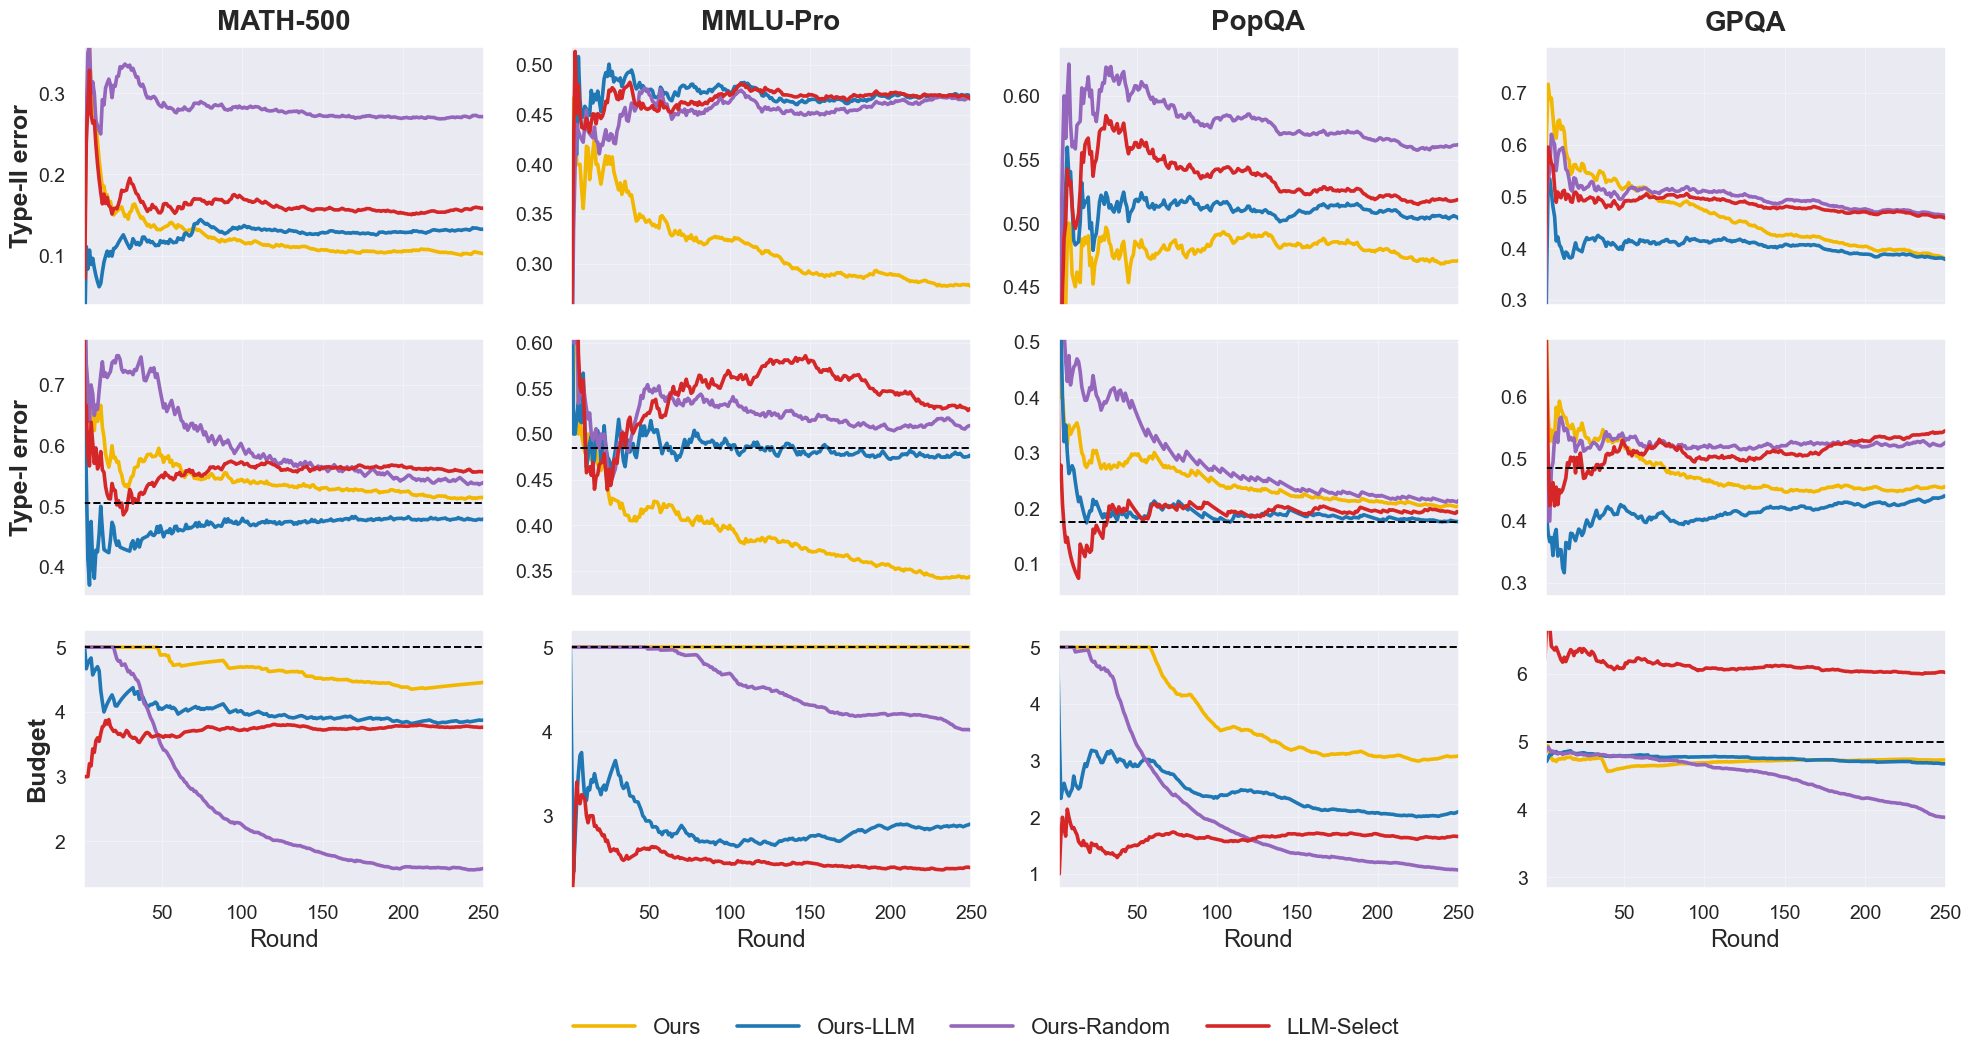

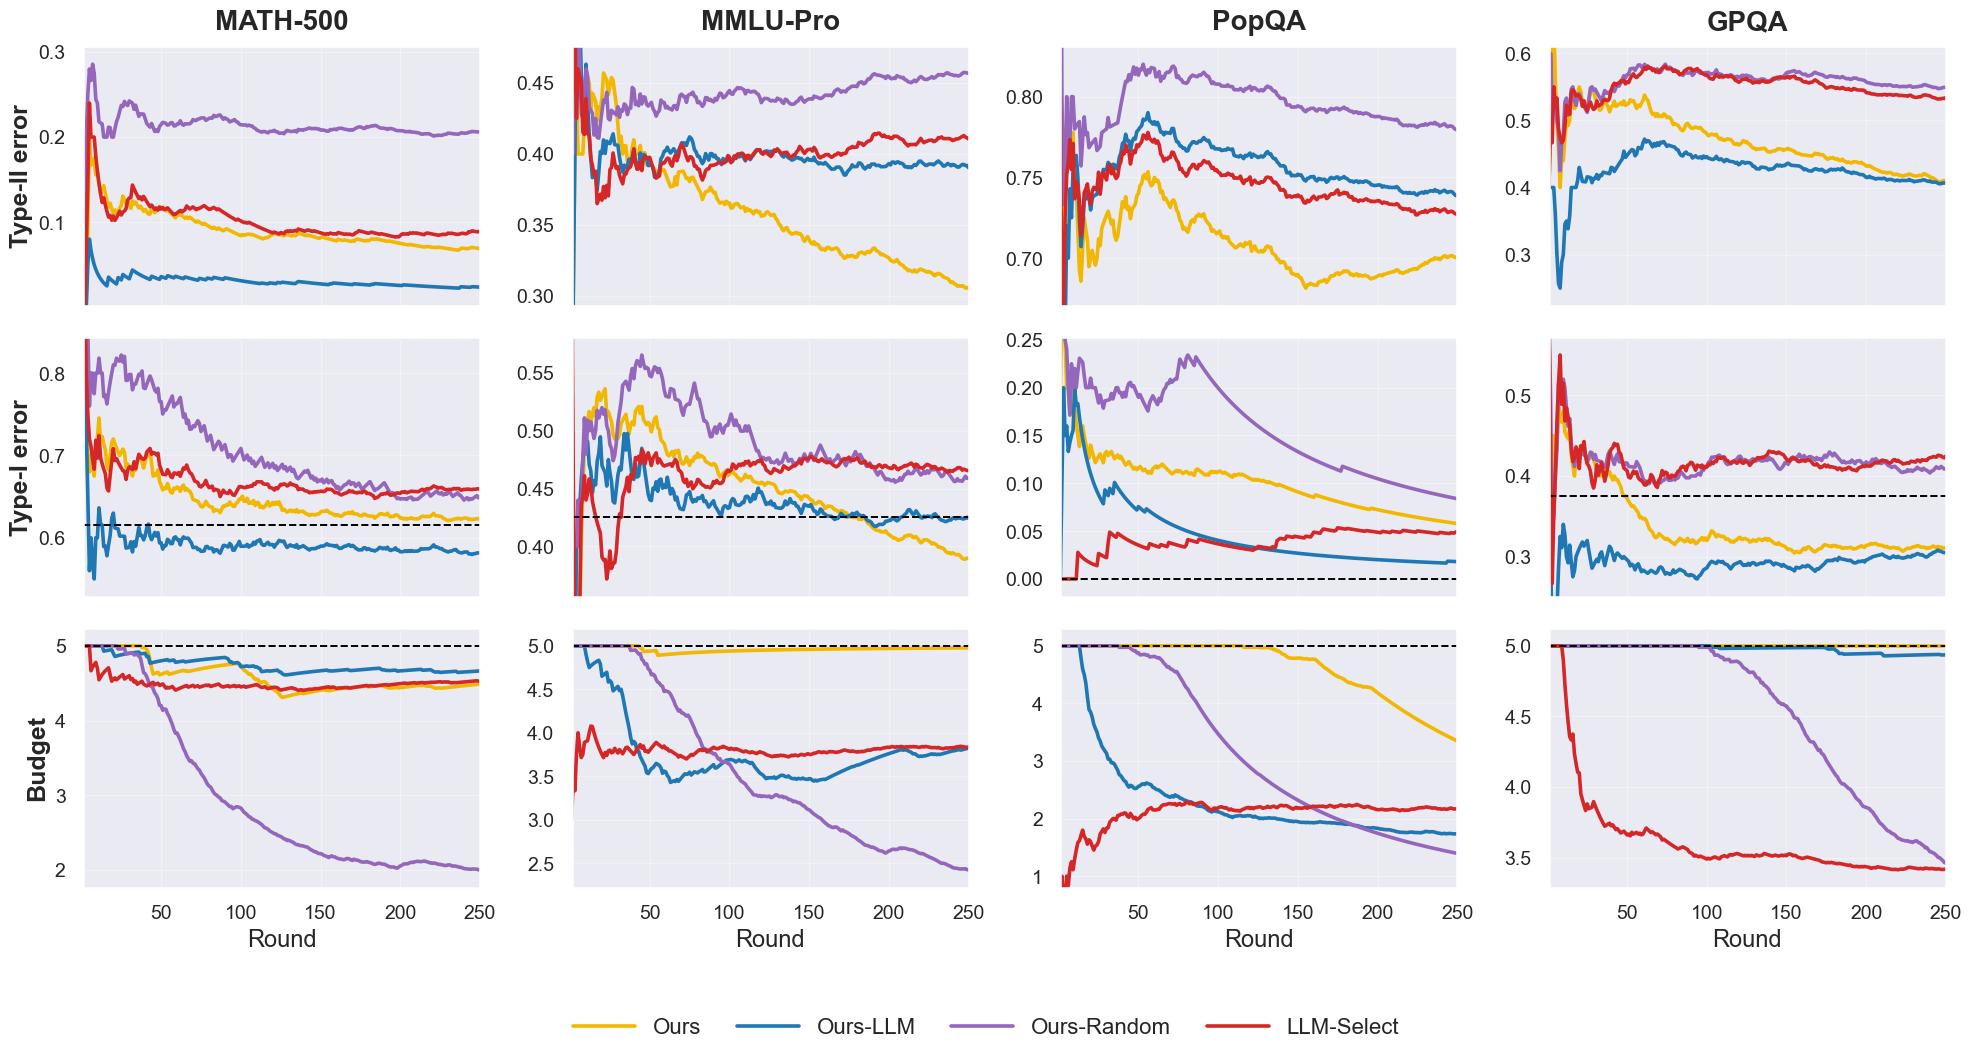

In [2]:
from pathlib import Path
from typing import Dict, List, Tuple
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(context="talk", style="darkgrid", font_scale=1.25)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 15,
    "legend.title_fontsize": 15,
    "figure.titlesize": 18,
})

# Change this if your outputs directory is elsewhere. Relative paths are resolved from the project root.
RUNS_TO_PLOT = ("outputs",)

DATASET_ORDER = [
    "math500-test",
    "mmlupro-test_n500_seed42",
    "popqa-test_n500_seed42",
    "gpqa-train_main_n448",
]

DATASET_LABELS = {
    "math500-test": "MATH-500",
    "mmlupro-test_n500_seed42": "MMLU-Pro",
    "popqa-test_n500_seed42": "PopQA",
    "gpqa-train_main_n448": "GPQA",
    "mmlupro-test_n600_seed42_multishift": "MMLU-Pro Shift",
    "popqa-test_n600_seed42_popshift": "PopQA Shift",
}

# Type-II is now first row.
ROW_SPECS = [
    ("Cum. Type-II", "Type-II error"),
    ("Cum. Type-I", "Type-I error"),
    ("Cum. Budget", "Budget"),
]


def dataset_display_name(dataset_id: str) -> str:
    """Return the paper-facing dataset label, not the config/folder suffix."""
    dataset_id = str(dataset_id).replace("popqa500-", "popqa-")

    if dataset_id in DATASET_LABELS:
        return DATASET_LABELS[dataset_id]
    if dataset_id.startswith("math500"):
        return "MATH-500"
    if dataset_id.startswith("mmlupro"):
        return "MMLU-Pro"
    if dataset_id.startswith("popqa"):
        return "PopQA"
    if dataset_id.startswith("gpqa"):
        return "GPQA"
    return dataset_id


def infer_model_name_for_plot(row: pd.Series) -> str:
    """Prefer the explicit main_llm column; otherwise strip the dataset suffix from model_data."""
    if "main_llm" in row.index and pd.notna(row["main_llm"]):
        text = str(row["main_llm"]).strip()
        if text:
            return text

    model_data = str(row.get("model_data", "unknown_model"))
    dataset = str(row.get("dataset", ""))

    if dataset and model_data.endswith("_" + dataset):
        return model_data[: -(len(dataset) + 1)]

    return model_data


def build_model_overview_metrics(runs=("outputs",)) -> pd.DataFrame:
    raw_df = collect_run_csvs(list(runs))
    raw_df["model"] = raw_df.apply(infer_model_name_for_plot, axis=1)

    per_round = summarize_per_round(raw_df)
    metrics = add_cumulative_metrics(per_round)
    metrics = maybe_add_epsilon(metrics, raw_df)

    model_lookup = (
        raw_df[["model_data", "dataset", "config", "method", "run_file", "model"]]
        .drop_duplicates()
    )

    metrics = metrics.merge(
        model_lookup,
        on=["model_data", "dataset", "config", "method", "run_file"],
        how="left",
    )

    metrics["Dataset Label"] = metrics["dataset"].map(dataset_display_name)
    metrics = filter_methods_for_plot(metrics)
    return metrics


def _dedupe_legend_items(handles, labels):
    seen = set()
    out_handles = []
    out_labels = []

    for h, label in zip(handles, labels):
        if not label or label.startswith("_") or label in seen:
            continue
        seen.add(label)
        out_handles.append(h)
        out_labels.append(label)

    return out_handles, out_labels


def plot_one_model_grid(
    metrics: pd.DataFrame,
    model: str,
    out_dir: str | Path = "figures/model_grids",
    dataset_order: List[str] = DATASET_ORDER,
) -> Tuple[plt.Figure, List[List[plt.Axes]]]:
    """
    Create one 3x4 figure for a single model.

    Rows:
      1. Type-II error
      2. Type-I error
      3. Budget

    Columns:
      1. MATH-500
      2. MMLU-Pro
      3. PopQA
      4. GPQA
    """
    model_df = metrics[metrics["model"] == model].copy()

    if model_df.empty:
        raise ValueError(f"No rows found for model={model!r}")

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(
        nrows=3,
        ncols=4,
        figsize=(20.0, 11.0),
        sharex=False,
        sharey=False,
        constrained_layout=False,
    )

    all_handles = []
    all_labels = []

    for col_idx, dataset_id in enumerate(dataset_order):
        dataset_df = model_df[model_df["dataset"] == dataset_id].copy()
        dataset_title = dataset_display_name(dataset_id)

        for row_idx, (metric_col, row_label) in enumerate(ROW_SPECS):
            ax = axes[row_idx][col_idx]

            if dataset_df.empty or metric_col not in dataset_df.columns:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=15,
                )
            else:
                dataset_df = filter_methods_for_plot(dataset_df)
                plot_df = _with_plot_round(dataset_df)
                reference_values: list[float] = []
                method_order = [
                    m for m in METHODS_TO_PLOT
                    if m in set(plot_df["Method"])
                ]

                sns.lineplot(
                    data=plot_df,
                    x="Plot Round",
                    y=metric_col,
                    hue="Method",
                    hue_order=method_order,
                    palette=METHOD_PALETTE,
                    linewidth=2.6,
                    errorbar=None,
                    ax=ax,
                    legend=True,
                )

                handles, labels = ax.get_legend_handles_labels()
                all_handles.extend(handles)
                all_labels.extend(labels)

                legend = ax.get_legend()
                if legend is not None:
                    legend.remove()

                if (
                    metric_col == "Cum. Type-I"
                    and "epsilon" in plot_df.columns
                    and plot_df["epsilon"].notna().any()
                ):
                    epsilon = float(plot_df["epsilon"].dropna().iloc[0])
                    reference_values.append(epsilon)
                    ax.axhline(
                        epsilon,
                        linestyle="--",
                        linewidth=1.4,
                        color="black",
                        label="_nolegend_",
                    )

                if (
                    metric_col == "Cum. Budget"
                    and "Limit" in plot_df.columns
                    and plot_df["Limit"].notna().any()
                ):
                    limit = float(plot_df["Limit"].dropna().iloc[0])
                    reference_values.append(limit)
                    ax.axhline(
                        limit,
                        linestyle="--",
                        linewidth=1.4,
                        color="black",
                        label="_nolegend_",
                    )

                _set_plot_limits(ax, plot_df, metric_col, reference_values=reference_values)

            # Dataset names only on the top row.
            if row_idx == 0:
                ax.set_title(dataset_title, fontsize=20, fontweight="bold", pad=12)
            else:
                ax.set_title("")

            # Keep y tick labels on every subplot because each panel has its own y-scale.
            # The y-axis label text is kept only on the leftmost subplot to avoid clutter.
            if col_idx == 0:
                ax.set_ylabel(row_label, fontsize=18, fontweight="bold")
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=True)

            # X-axis labels only on bottom row.
            if row_idx == 2:
                ax.set_xlabel("Round", fontsize=17)
            else:
                ax.set_xlabel("")
                ax.tick_params(labelbottom=False)

            ax.tick_params(axis="both", labelsize=14)
            ax.grid(True, alpha=0.35, linewidth=0.8)

    handles, labels = _dedupe_legend_items(all_handles, all_labels)

    if handles:
        fig.legend(
            handles,
            labels,
            title=None,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.005),
            ncol=min(len(labels), 6),
            frameon=False,
            fontsize=16,
            handlelength=2.8,
            columnspacing=1.6,
        )

    # No model name above the plots.
    fig.tight_layout(rect=(0.0, 0.08, 1.0, 0.98), w_pad=1.4, h_pad=1.2)

    out_png = out_dir / f"model_grid_{safe_name(model)}.png"
    out_pdf = out_dir / f"model_grid_{safe_name(model)}.pdf"

    fig.savefig(out_png, bbox_inches="tight", dpi=300)
    fig.savefig(out_pdf, bbox_inches="tight")

    print(f"[plot] wrote {out_png}")
    print(f"[plot] wrote {out_pdf}")

    return fig, axes


metrics = build_model_overview_metrics(runs=RUNS_TO_PLOT)

for model_name in sorted(metrics["model"].dropna().unique()):
    plot_one_model_grid(metrics, model_name)

[plot] scanned 67 CSV files; loaded 55 method-run CSV files.
[plot] discovered run groups:
  - llama-3.3-70b-versatile_gpqa-train_main_n448  |  gpqa-train_main_n448
  - llama-3.3-70b-versatile_math500-test  |  math500-test
  - llama-3.3-70b-versatile_mmlupro-test_n500_seed42  |  mmlupro-test_n500_seed42
  - llama-3.3-70b-versatile_mmlupro-test_n600_seed42_multishift  |  mmlupro-test_n600_seed42_multishift
  - llama-3.3-70b-versatile_popqa-test_n500_seed42  |  popqa-test_n500_seed42
  - llama-3.3-70b-versatile_popqa-test_n600_seed42_popshift  |  popqa-test_n600_seed42_popshift
  - qwen-qwen3-32b_gpqa-train_main_n448  |  gpqa-train_main_n448
  - qwen-qwen3-32b_math500-test  |  math500-test
  - qwen-qwen3-32b_mmlupro-test_n500_seed42  |  mmlupro-test_n500_seed42
  - qwen-qwen3-32b_popqa-test_n500_seed42  |  popqa-test_n500_seed42
[plot] wrote figures\review_length_model_grids\review_length_model_grid_llama-3.3-70b-versatile.png
[plot] wrote figures\review_length_model_grids\review_length_

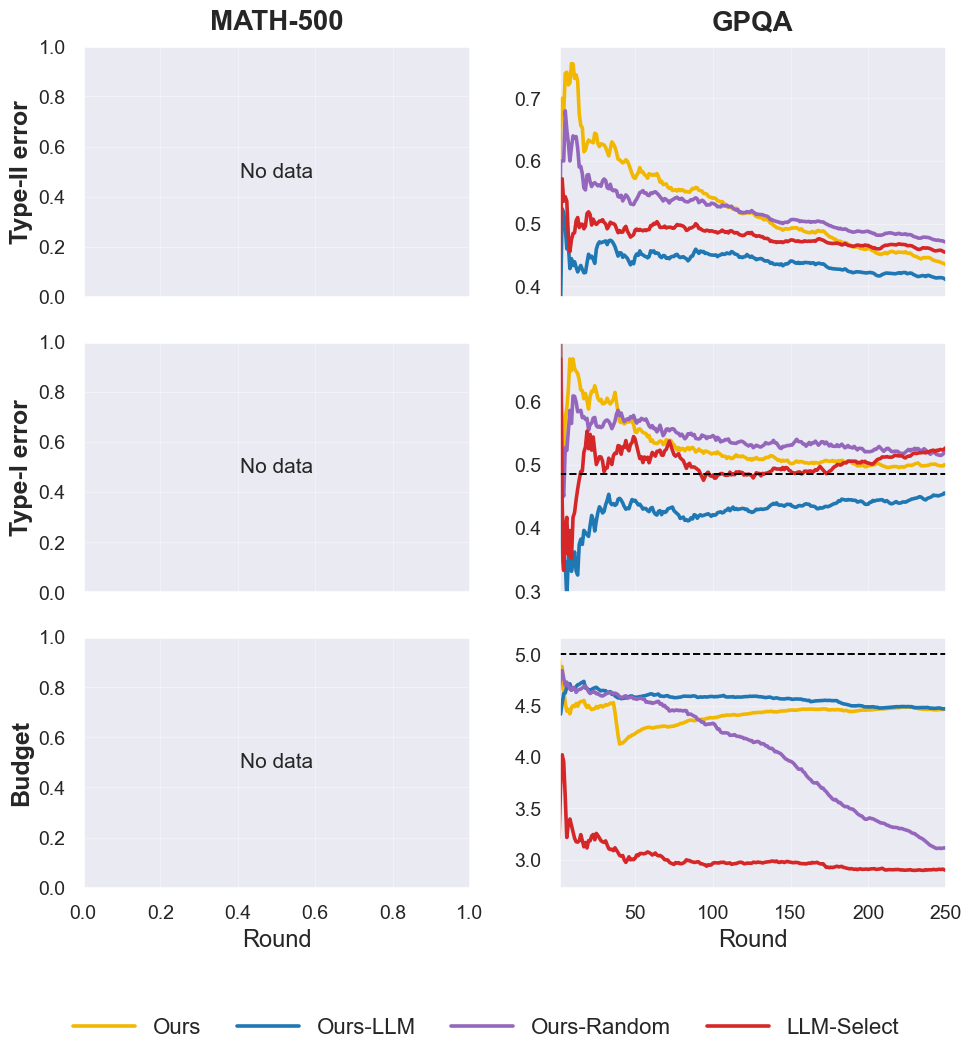

In [3]:
# Review-length-cost experiments figure
# Run this cell after the standard plotting/helper cells above.
# It reuses the same plotting style, method colors, cumulative metrics, and
# y-axis limit logic as the first main model-grid plots.

from pathlib import Path
from typing import List, Tuple

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

REVIEW_LENGTH_RUNS_TO_PLOT = ("outputs",)

REVIEW_LENGTH_DATASET_ORDER = [
    "math500-test_review_length",
    "gpqa-train_main_n448_review_length",
]

REVIEW_LENGTH_DATASET_LABELS = {
    "math500-test_review_length": "MATH-500",
    "gpqa-train_main_n448_review_length": "GPQA",
}


def review_length_dataset_display_name(dataset_id: str) -> str:
    """Paper-facing label for review-length-cost datasets."""
    return REVIEW_LENGTH_DATASET_LABELS.get(str(dataset_id), dataset_display_name(dataset_id))


def _is_review_length_text(text: object) -> bool:
    text = str(text).lower().replace("-", "_")
    return "review_length" in text or "reviewlength" in text


def _review_length_dataset_from_text(text: object) -> str | None:
    """Recover the review-length experiment id from config names, CSV names, or paths."""
    normalized = str(text).lower().replace("\\", "/").replace("-", "_")
    if "review_length" not in normalized and "reviewlength" not in normalized:
        return None

    if "math500" in normalized or "math_500" in normalized:
        return "math500-test_review_length"
    if "gpqa" in normalized:
        return "gpqa-train_main_n448_review_length"
    return None


def _normalize_review_length_dataset_row(row: pd.Series) -> str | None:
    """Normalize rows from review-length output folders to the canonical ids above."""
    candidates = [
        row.get("dataset", ""),
        row.get("model_data", ""),
        row.get("config", ""),
        row.get("run_file", ""),
        row.get("run_path", ""),
    ]
    for value in candidates:
        dataset = _review_length_dataset_from_text(value)
        if dataset:
            return dataset
    return None


def infer_review_length_model_name(row: pd.Series) -> str:
    """Infer model name for review-length runs without relying on old dataset parsing."""
    if "main_llm" in row.index and pd.notna(row["main_llm"]):
        text = str(row["main_llm"]).strip()
        if text:
            return text

    dataset = str(row.get("dataset", ""))
    run_path = str(row.get("run_path", ""))
    parent = safe_name(Path(run_path).parent.name) if run_path else str(row.get("model_data", "unknown_model"))

    if dataset and parent.endswith("_" + safe_name(dataset)):
        return parent[: -(len(safe_name(dataset)) + 1)]

    # Common output-folder names look like:
    #   {model}_math500-test_review_length
    #   {model}_gpqa-train_main_n448_review_length
    for suffix in [
        "_math500-test_review_length",
        "_gpqa-train_main_n448_review_length",
    ]:
        safe_suffix = safe_name(suffix).lstrip("_")
        if parent.endswith("_" + safe_suffix):
            return parent[: -(len(safe_suffix) + 1)]

    model_data = str(row.get("model_data", "unknown_model"))
    for suffix in [
        "_math500-test_review_length",
        "_gpqa-train_main_n448_review_length",
        "_math500-test",
        "_gpqa-train_main_n448",
    ]:
        if model_data.endswith(suffix):
            return model_data[: -len(suffix)]

    return model_data


def build_review_length_metrics(runs=("outputs",)) -> pd.DataFrame:
    """Collect only review-length-cost runs and compute cumulative plotting metrics."""
    raw_df = collect_run_csvs(list(runs))
    raw_df["dataset"] = raw_df.apply(_normalize_review_length_dataset_row, axis=1)
    raw_df = raw_df[raw_df["dataset"].notna()].copy()

    if raw_df.empty:
        raise RuntimeError(
            "No review-length run CSVs were found. Expected outputs such as "
            "outputs/*_math500-test_review_length/*.csv or "
            "outputs/*_gpqa-train_main_n448_review_length/*.csv."
        )

    raw_df["model"] = raw_df.apply(infer_review_length_model_name, axis=1)

    per_round = summarize_per_round(raw_df)
    metrics = add_cumulative_metrics(per_round)
    metrics = maybe_add_epsilon(metrics, raw_df)

    model_lookup = (
        raw_df[["model_data", "dataset", "config", "method", "run_file", "model"]]
        .drop_duplicates()
    )
    metrics = metrics.merge(
        model_lookup,
        on=["model_data", "dataset", "config", "method", "run_file"],
        how="left",
    )

    metrics["Dataset Label"] = metrics["dataset"].map(review_length_dataset_display_name)
    metrics = filter_methods_for_plot(metrics)
    return metrics


def plot_one_review_length_model_grid(
    metrics: pd.DataFrame,
    model: str,
    out_dir: str | Path = "figures/review_length_model_grids",
    dataset_order: List[str] = REVIEW_LENGTH_DATASET_ORDER,
) -> Tuple[plt.Figure, List[List[plt.Axes]]]:
    """
    Create one review-length-cost figure for a single model.

    Rows:
      1. Type-II error
      2. Type-I error
      3. Budget

    Columns:
      Review-length datasets currently implemented in the codebase.
    """
    model_df = metrics[metrics["model"] == model].copy()
    if model_df.empty:
        raise ValueError(f"No rows found for model={model!r}")

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    ncols = len(dataset_order)
    fig_width = max(10.0, 5.0 * ncols)
    fig, axes = plt.subplots(
        nrows=3,
        ncols=ncols,
        figsize=(fig_width, 11.0),
        sharex=False,
        sharey=False,
        constrained_layout=False,
    )

    if ncols == 1:
        axes = [[axes[row_idx]] for row_idx in range(3)]

    all_handles = []
    all_labels = []

    for col_idx, dataset_id in enumerate(dataset_order):
        dataset_df = model_df[model_df["dataset"] == dataset_id].copy()
        dataset_title = review_length_dataset_display_name(dataset_id)

        for row_idx, (metric_col, row_label) in enumerate(ROW_SPECS):
            ax = axes[row_idx][col_idx]

            if dataset_df.empty or metric_col not in dataset_df.columns:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=15,
                )
            else:
                dataset_df = filter_methods_for_plot(dataset_df)
                plot_df = _with_plot_round(dataset_df)
                reference_values: list[float] = []
                method_order = [m for m in METHODS_TO_PLOT if m in set(plot_df["Method"])]

                sns.lineplot(
                    data=plot_df,
                    x="Plot Round",
                    y=metric_col,
                    hue="Method",
                    hue_order=method_order,
                    palette=METHOD_PALETTE,
                    linewidth=2.6,
                    errorbar=None,
                    ax=ax,
                    legend=True,
                )

                handles, labels = ax.get_legend_handles_labels()
                all_handles.extend(handles)
                all_labels.extend(labels)

                legend = ax.get_legend()
                if legend is not None:
                    legend.remove()

                if (
                    metric_col == "Cum. Type-I"
                    and "epsilon" in plot_df.columns
                    and plot_df["epsilon"].notna().any()
                ):
                    epsilon = float(plot_df["epsilon"].dropna().iloc[0])
                    reference_values.append(epsilon)
                    ax.axhline(
                        epsilon,
                        linestyle="--",
                        linewidth=1.4,
                        color="black",
                        label="_nolegend_",
                    )

                if (
                    metric_col == "Cum. Budget"
                    and "Limit" in plot_df.columns
                    and plot_df["Limit"].notna().any()
                ):
                    limit = float(plot_df["Limit"].dropna().iloc[0])
                    reference_values.append(limit)
                    ax.axhline(
                        limit,
                        linestyle="--",
                        linewidth=1.4,
                        color="black",
                        label="_nolegend_",
                    )

                _set_plot_limits(ax, plot_df, metric_col, reference_values=reference_values)

            if row_idx == 0:
                ax.set_title(dataset_title, fontsize=20, fontweight="bold", pad=12)
            else:
                ax.set_title("")

            if col_idx == 0:
                ax.set_ylabel(row_label, fontsize=18, fontweight="bold")
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=True)

            if row_idx == 2:
                ax.set_xlabel("Round", fontsize=17)
            else:
                ax.set_xlabel("")
                ax.tick_params(labelbottom=False)

            ax.tick_params(axis="both", labelsize=14)
            ax.grid(True, alpha=0.35, linewidth=0.8)

    handles, labels = _dedupe_legend_items(all_handles, all_labels)
    if handles:
        fig.legend(
            handles,
            labels,
            title=None,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.005),
            ncol=min(len(labels), 6),
            frameon=False,
            fontsize=16,
            handlelength=2.8,
            columnspacing=1.6,
        )

    fig.tight_layout(rect=(0.0, 0.08, 1.0, 0.98), w_pad=1.4, h_pad=1.2)

    out_png = out_dir / f"review_length_model_grid_{safe_name(model)}.png"
    out_pdf = out_dir / f"review_length_model_grid_{safe_name(model)}.pdf"

    fig.savefig(out_png, bbox_inches="tight", dpi=300)
    fig.savefig(out_pdf, bbox_inches="tight")

    print(f"[plot] wrote {out_png}")
    print(f"[plot] wrote {out_pdf}")

    return fig, axes


review_length_metrics = build_review_length_metrics(runs=REVIEW_LENGTH_RUNS_TO_PLOT)

for model_name in sorted(review_length_metrics["model"].dropna().unique()):
    plot_one_review_length_model_grid(review_length_metrics, model_name)


[plot] scanned 67 CSV files; loaded 55 method-run CSV files.
[plot] discovered run groups:
  - llama-3.3-70b-versatile_gpqa-train_main_n448  |  gpqa-train_main_n448
  - llama-3.3-70b-versatile_math500-test  |  math500-test
  - llama-3.3-70b-versatile_mmlupro-test_n500_seed42  |  mmlupro-test_n500_seed42
  - llama-3.3-70b-versatile_mmlupro-test_n600_seed42_multishift  |  mmlupro-test_n600_seed42_multishift
  - llama-3.3-70b-versatile_popqa-test_n500_seed42  |  popqa-test_n500_seed42
  - llama-3.3-70b-versatile_popqa-test_n600_seed42_popshift  |  popqa-test_n600_seed42_popshift
  - qwen-qwen3-32b_gpqa-train_main_n448  |  gpqa-train_main_n448
  - qwen-qwen3-32b_math500-test  |  math500-test
  - qwen-qwen3-32b_mmlupro-test_n500_seed42  |  mmlupro-test_n500_seed42
  - qwen-qwen3-32b_popqa-test_n500_seed42  |  popqa-test_n500_seed42
[plot] wrote figures\distribution_shift\distribution_shift_robustness.png
[plot] wrote figures\distribution_shift\distribution_shift_robustness.pdf


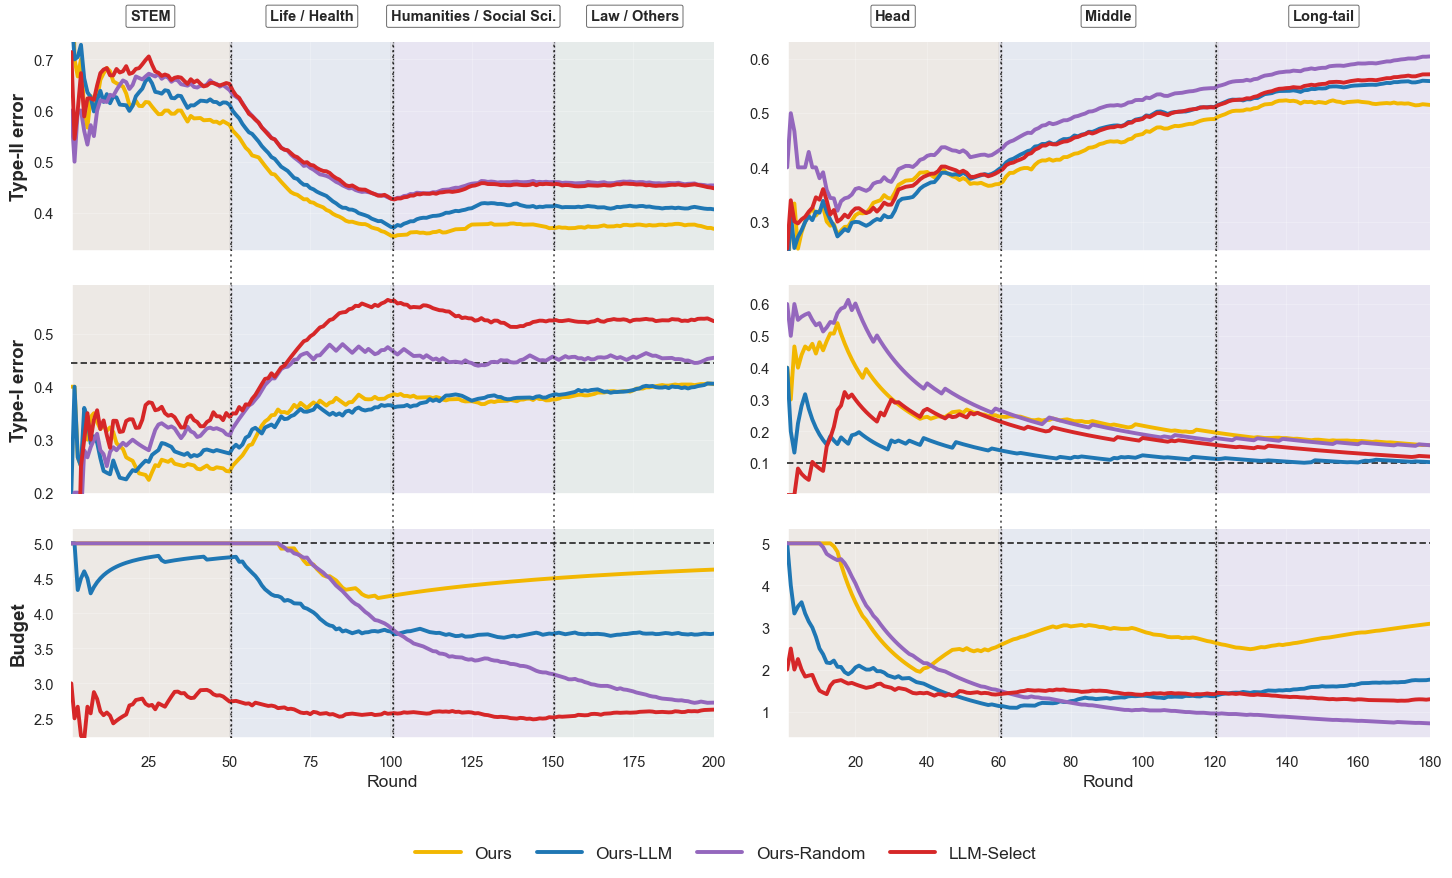

In [4]:
# Distribution-shift robustness figure
# Run this cell after the standard plotting/helper cells above.

from matplotlib.lines import Line2D
from matplotlib.transforms import blended_transform_factory

SHIFT_EXPERIMENT_SPECS = {
    "mmlupro-test_n600_seed42_multishift": {
        "subtitle": "STEM → Life/Health → Humanities/Social Science → Law/Others",
        "phases": [
            (0, 49, "STEM"),
            (50, 99, "Life / Health"),
            (100, 149, "Humanities / Social Sci."),
            (150, 199, "Law / Others"),
        ],
    },
    "popqa-test_n600_seed42_popshift": {
        "subtitle": "Head entities → Mid-popularity entities → Long-tail entities",
        "phases": [
            (0, 59, "Head"),
            (60, 119, "Middle"),
            (120, 179, "Long-tail"),
        ],
    },
}

SHIFT_METRICS_TO_PLOT = [
    ("Cum. Type-II", "Type-II error"),
    ("Cum. Type-I", "Type-I error"),
    ("Cum. Budget", "Budget"),
]


def _normalize_shift_dataset_row(row: pd.Series) -> str:
    """Recover the shift dataset id even for legacy CSVs with short dataset columns."""
    dataset = str(row.get("dataset", ""))
    text = " ".join(str(row.get(col, "")) for col in ["run_file", "run_path", "config"]).lower()

    if "multishift" in text and "mmlupro" in text:
        return "mmlupro-test_n600_seed42_multishift"
    if "popshift" in text and "popqa" in text:
        return "popqa-test_n600_seed42_popshift"
    return dataset


def build_shift_metrics(runs=("outputs",)) -> pd.DataFrame:
    """Collect only the new distribution-shift runs."""
    raw_df = collect_run_csvs(list(runs))
    raw_df["dataset"] = raw_df.apply(_normalize_shift_dataset_row, axis=1)
    per_round = summarize_per_round(raw_df)
    metrics = add_cumulative_metrics(per_round)
    metrics = maybe_add_epsilon(metrics, raw_df)
    metrics = filter_methods_for_plot(metrics)
    return metrics[metrics["dataset"].isin(SHIFT_EXPERIMENT_SPECS)].copy()


def _phase_color(index: int) -> str:
    # Low-saturation phase wash. These colors are deliberately subtle so the
    # method curves remain the visual foreground in paper figures.
    colors = ["#F6E8C3", "#D8E8F1", "#E6D8F2", "#DDEED6", "#F3D6D8"]
    return colors[index % len(colors)]


def _phase_span_for_plot(start: int, end: int) -> tuple[float, float]:
    # Original batches are zero-based; plotted batches are one-based.
    return start + 1, end + 1


def _phase_edge_for_plot(start: int) -> float:
    # Boundary between previous phase ending at start and the new phase's first
    # one-based batch at start + 1.
    return start + 0.5


def decorate_shift_axis(ax, phases, show_phase_labels: bool = False) -> None:
    """Add phase bands and optionally one row of phase labels above the top axes."""
    trans = blended_transform_factory(ax.transData, ax.transAxes)

    for idx, (start, end, label) in enumerate(phases):
        x0, x1 = _phase_span_for_plot(start, end)
        ax.axvspan(x0, x1, color=_phase_color(idx), alpha=0.26, lw=0, zorder=0)

        if show_phase_labels:
            mid = (x0 + x1) / 2.0
            ax.text(
                mid,
                1.09,
                label,
                ha="center",
                va="bottom",
                transform=trans,
                fontsize=10.5,
                fontweight="semibold",
                bbox={
                    "boxstyle": "round,pad=0.28,rounding_size=0.12",
                    "fc": "white",
                    "ec": "0.35",
                    "lw": 0.65,
                    "alpha": 0.96,
                },
                clip_on=False,
                zorder=7,
            )

    # Thin local guide lines inside each subplot; the figure-level guides below
    # connect these across rows as continuous dotted shift edges.
    for start, _, _ in phases[1:]:
        edge = _phase_edge_for_plot(start)
        ax.axvspan(edge - 0.7, edge + 0.7, color="black", alpha=0.045, lw=0, zorder=1)
        ax.axvline(edge, color="0.12", lw=0.9, linestyle=(0, (1.2, 2.2)), zorder=4)

    ax.set_xlim(phases[0][0] + 1, phases[-1][1] + 1)
    ax.grid(True, alpha=0.25, linewidth=0.75)


def _draw_column_shift_guides(fig: plt.Figure, axes_col: list[plt.Axes], phases) -> None:
    """Draw dotted shift boundaries continuously from top subplot to bottom subplot."""
    fig.canvas.draw()
    top_ax = axes_col[0]
    bottom_ax = axes_col[-1]
    y0 = bottom_ax.get_position().y0
    y1 = top_ax.get_position().y1

    for start, _, _ in phases[1:]:
        edge = _phase_edge_for_plot(start)
        x_display = top_ax.transData.transform((edge, 0))[0]
        x_fig = fig.transFigure.inverted().transform((x_display, 0))[0]
        fig.add_artist(
            Line2D(
                [x_fig, x_fig],
                [y0, y1],
                transform=fig.transFigure,
                color="0.10",
                linewidth=1.2,
                linestyle=(0, (1.2, 2.2)),
                alpha=0.78,
                zorder=20,
                clip_on=False,
            )
        )


def plot_distribution_shift_figure(
    runs=("outputs",),
    out_dir: str | Path = "figures/distribution_shift",
    metrics_to_plot=SHIFT_METRICS_TO_PLOT,
):
    """Create the paper-ready distribution-shift robustness figure."""
    shift_metrics = build_shift_metrics(runs=runs)
    if shift_metrics.empty:
        raise RuntimeError(
            "No distribution-shift run CSVs found. Run the new multishift/popshift configs first."
        )

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    dataset_ids = [d for d in SHIFT_EXPERIMENT_SPECS if d in set(shift_metrics["dataset"])]
    fig, axes = plt.subplots(
        nrows=len(metrics_to_plot),
        ncols=len(dataset_ids),
        figsize=(7.4 * len(dataset_ids), 9.0),
        sharex=False,
        sharey=False,
        constrained_layout=False,
    )
    if len(metrics_to_plot) == 1:
        axes = [axes]
    if len(dataset_ids) == 1:
        axes = [[ax] for ax in axes]

    all_handles = []
    all_labels = []

    for col_idx, dataset_id in enumerate(dataset_ids):
        spec = SHIFT_EXPERIMENT_SPECS[dataset_id]
        dataset_df = shift_metrics[shift_metrics["dataset"] == dataset_id].copy()
        dataset_df = _with_plot_round(dataset_df)
        method_order = [m for m in METHODS_TO_PLOT if m in set(dataset_df["Method"])]

        for row_idx, (metric_col, y_label) in enumerate(metrics_to_plot):
            ax = axes[row_idx][col_idx]
            decorate_shift_axis(ax, spec["phases"], show_phase_labels=(row_idx == 0))

            sns.lineplot(
                data=dataset_df,
                x="Plot Round",
                y=metric_col,
                hue="Method",
                hue_order=method_order,
                palette=METHOD_PALETTE,
                linewidth=2.8,
                errorbar=None,
                ax=ax,
                legend=True,
                zorder=5,
            )

            handles, labels = ax.get_legend_handles_labels()
            all_handles.extend(handles)
            all_labels.extend(labels)
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

            reference_values: list[float] = []
            if metric_col == "Cum. Type-I" and "epsilon" in dataset_df.columns and dataset_df["epsilon"].notna().any():
                epsilon = float(dataset_df["epsilon"].dropna().iloc[0])
                reference_values.append(epsilon)
                ax.axhline(epsilon, color="0.10", lw=1.15, linestyle=(0, (4, 2)), zorder=4)

            if metric_col == "Cum. Budget" and "Limit" in dataset_df.columns and dataset_df["Limit"].notna().any():
                limit = float(dataset_df["Limit"].dropna().iloc[0])
                reference_values.append(limit)
                ax.axhline(limit, color="0.10", lw=1.15, linestyle=(0, (4, 2)), zorder=4)

            _set_plot_limits(ax, dataset_df, metric_col, reference_values=reference_values)
            ax.set_xlim(spec["phases"][0][0] + 1, spec["phases"][-1][1] + 1)

            # if row_idx == 0:
            #     ax.set_title(spec["title"], fontsize=14.5, fontweight="bold", pad=34)
            # else:
            #     ax.set_title("")

            # Each distribution-shift subplot has its own y-scale, so keep y tick labels everywhere.
            if col_idx == 0:
                ax.set_ylabel(y_label, fontsize=13.5, fontweight="bold")
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=True)
            if row_idx == len(metrics_to_plot) - 1:
                ax.set_xlabel("Round", fontsize=12.5)
            else:
                ax.set_xlabel("")
                ax.tick_params(labelbottom=False)

            ax.tick_params(axis="both", labelsize=10.5)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    handles, labels = _dedupe_legend_items(all_handles, all_labels)
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.005),
            ncol=min(len(labels), 5),
            frameon=False,
            fontsize=12.5,
            handlelength=2.6,
            columnspacing=1.4,
        )

    # No overall figure title: the columns carry the dataset titles.
    fig.tight_layout(rect=(0.0, 0.065, 1.0, 0.985), w_pad=1.6, h_pad=1.25)

    for col_idx, dataset_id in enumerate(dataset_ids):
        axes_col = [axes[row_idx][col_idx] for row_idx in range(len(metrics_to_plot))]
        _draw_column_shift_guides(fig, axes_col, SHIFT_EXPERIMENT_SPECS[dataset_id]["phases"])

    out_png = out_dir / "distribution_shift_robustness.png"
    out_pdf = out_dir / "distribution_shift_robustness.pdf"
    fig.savefig(out_png, bbox_inches="tight", dpi=300)
    fig.savefig(out_pdf, bbox_inches="tight")
    print(f"[plot] wrote {out_png}")
    print(f"[plot] wrote {out_pdf}")
    return fig, axes, shift_metrics


shift_fig, shift_axes, shift_metrics = plot_distribution_shift_figure(runs=RUNS_TO_PLOT)
